<a href="https://colab.research.google.com/github/anujpurohit0501/Loan_Prediction/blob/main/Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Loan Amount Prediction using Machine Learning



##### **Project Type**    - EDA/Regression
##### **Contribution** -Individual
##### **Name**            - Anuj Purohit

# **Project Summary -**

Write the summary here within 500-600 words.

The Loan Amount Prediction project aims to analyze customer information and predict the amount of loan that can be granted based on various applicant characteristics. Financial institutions receive thousands of loan applications every day, making manual analysis both time-consuming and prone to inconsistencies. Machine Learning provides an efficient solution by learning patterns from historical applicant data and generating accurate predictions.

This project uses a loan dataset containing demographic, financial, and property-related information of applicants. Important attributes include Gender, Marital Status, Education, Dependents, Applicant Income, Co-applicant Income, Credit History, Loan Amount Term, Self Employment Status, and Property Area. The target variable selected for prediction is LoanAmount, making this a supervised regression problem.

The project begins with Exploratory Data Analysis (EDA) to understand the structure of the dataset. Missing values, duplicate records, and data types are identified before performing preprocessing. Missing numerical values are filled using the median while categorical missing values are replaced using the mode. Categorical variables are converted into numerical format through label encoding to make the dataset suitable for machine learning algorithms.

Several visualization techniques are used to understand the distribution of variables and relationships among different features. Histograms, bar charts, scatter plots, box plots, heatmaps, and pair plots provide valuable insights into applicant income, loan amount distribution, property areas, education levels, and other important factors affecting loan amounts.

Multiple regression algorithms are implemented to compare prediction performance. Linear Regression serves as the baseline model, while Ridge Regression and Lasso Regression help reduce overfitting through regularization. Decision Tree Regressor and Random Forest Regressor are also applied to capture complex non-linear relationships present in the dataset. The models are evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Cross-validation and hyperparameter tuning are performed to improve model generalization and ensure stable performance across different data splits. Finally, the best-performing model is selected based on evaluation metrics and business relevance.

The insights generated through this project can help financial institutions estimate suitable loan amounts more efficiently, reduce manual effort, improve consistency in decision making, and enhance customer service by providing quicker loan assessments.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

Banks and financial institutions receive a large number of loan applications from customers having different financial backgrounds. Determining the appropriate loan amount for every applicant through manual analysis is time-consuming and may lead to inconsistent decisions.

The objective of this project is to develop a Machine Learning model capable of predicting the loan amount based on applicant details such as income, education, marital status, credit history, employment status, dependents, property area, and loan term.

The project focuses on cleaning the dataset, performing exploratory data analysis, preprocessing the data, building multiple regression models, evaluating their performance, and selecting the most accurate model for predicting loan amounts.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [93]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Dataset Loading

In [94]:
# Load Dataset


path ='/test_Y3wMUE5_7gLdaTN.csv'


df=pd.read_csv(path)

### Dataset First View

In [95]:
# Dataset First Look
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


### Dataset Rows & Columns count

In [96]:
# Dataset Rows & Columns count
df.shape

(367, 12)

### Dataset Information

In [97]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


#### Duplicate Values

In [98]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [99]:
# Missing Values/Null Values Count
df.isnull().sum()
df = df.drop_duplicates()

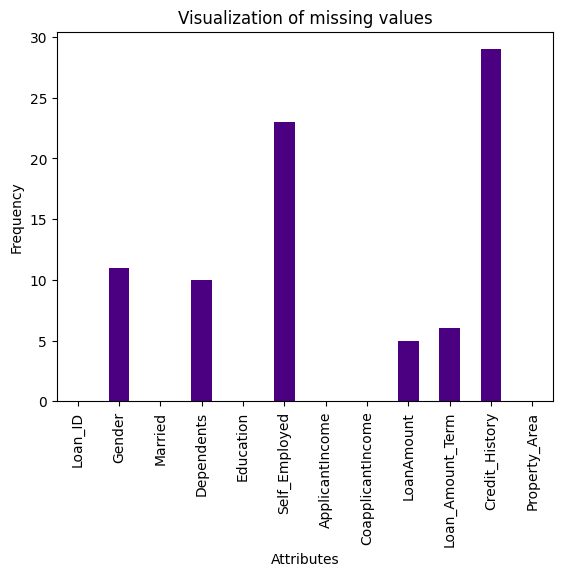

In [100]:
# Visualizing the missing values
x=df.isnull().sum()
x.plot(kind='bar',color='indigo')
plt.xlabel('Attributes')
plt.ylabel('Frequency')
plt.title('Visualization of missing values')
plt.show()


### What did you know about your dataset?

Answer : I found duplicate records and some missing values in certain columns. Visualizing them helped identify data quality issues and guided the cleaning process before analysis.

## ***2. Understanding Your Variables***

In [101]:
# Dataset Columns
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [102]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


### Variables Description

Loan_ID : Unique identification number of each loan application.

Gender : Gender of the applicant.

Married : Marital status of the applicant.

Dependents : Number of dependents.

Education : Educational qualification of the applicant.

Self_Employed : Whether the applicant is self-employed.

ApplicantIncome : Monthly income of the primary applicant.

CoapplicantIncome : Monthly income of the co-applicant.

LoanAmount : Loan amount requested by the applicant (Target Variable).

Loan_Amount_Term : Duration of the loan repayment in months.

Credit_History : Indicates whether the applicant has a good credit history.

Property_Area : Area where the applicant's property is located (Urban, Semiurban, Rural).


### Check Unique Values for each variable.

In [103]:
# Check Unique Values for each variable.
df.nunique()

,0
Loan_ID,367
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,314
CoapplicantIncome,194
LoanAmount,144
Loan_Amount_Term,12


## 3. ***Data Wrangling***

### Data Wrangling Code

In [104]:
# Write your code to make your dataset analysis ready.
df['Married']=df['Married'].map({'Yes':1,'No':0})
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df['Education']=df['Education'].map({'Graduate':1,'Not Graduate':0})
df['Self_Employed']=df['Self_Employed'].map({'Yes':1,'No':0})
df['Property_Area']=df['Property_Area'].map({'Urban':2,'Rural':0,'Semiurban':1})
df = df.drop('Loan_ID', axis=1)
df['Dependents'] = df['Dependents'].replace('3+', 3)

### What all manipulations have you done and insights you found?

Several preprocessing steps were performed to prepare the dataset for machine learning. The Loan_ID column was removed since it does not contribute to prediction. Categorical variables such as Gender, Married, Education, Self_Employed, and Property_Area were encoded into numerical values. The Dependents column was cleaned by replacing the value '3+' with 3. Missing values were handled using suitable statistical methods before model training. These transformations converted the raw dataset into a clean numerical dataset suitable for regression algorithms.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

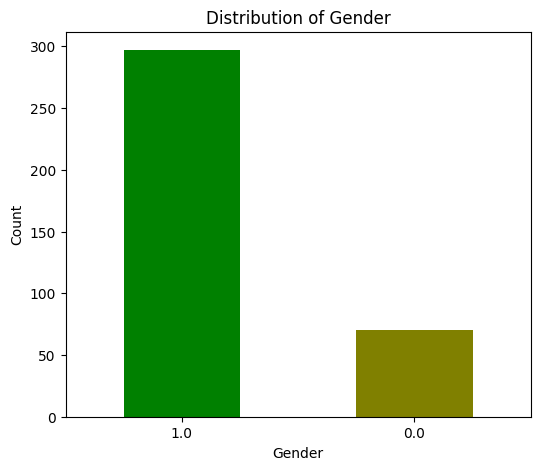

In [160]:
# Chart - 1 visualization code
plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(kind='bar', color=['Green','olive'])

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :A bar chart clearly shows the distribution of applicants based on gender.

##### 2. What is/are the insight(s) found from the chart?



```
# This is formatted as code
```

Answer : The dataset contains more male applicants than female applicants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Understanding applicant demographics helps banks analyze customer distribution and design targeted financial products.

#### Chart - 2

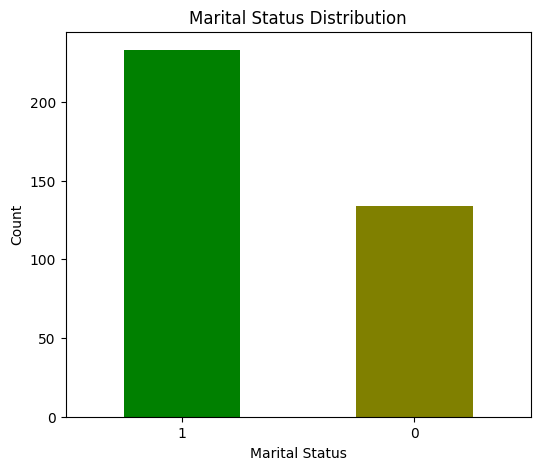

In [162]:
# Chart - 2 visualization code
plt.figure(figsize=(6,5))

df['Married'].value_counts().plot(kind='bar', color=['green','olive'])

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : To understand the proportion of married and unmarried applicants.

##### 2. What is/are the insight(s) found from the chart?

Answer : Most applicants are married.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Marital status may influence repayment capability and financial responsibility.

#### Chart - 3

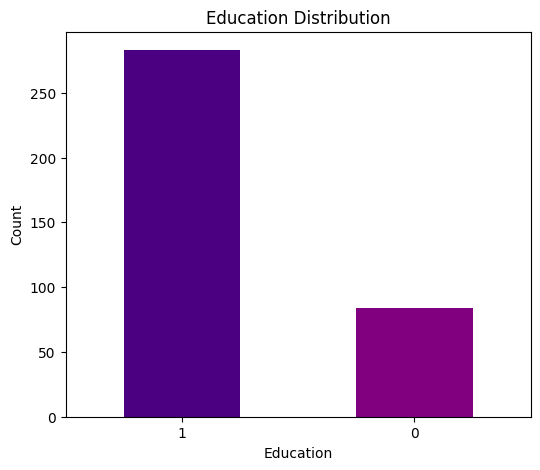

In [173]:
# Chart - 3 visualization code
plt.figure(figsize=(6,5))

df['Education'].value_counts().plot(kind='bar', color=['indigo','purple'])

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : Education is an important socio-economic feature.

##### 2. What is/are the insight(s) found from the chart?

Answer : Graduate applicants dominate the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Banks may observe different borrowing behaviour across education levels.

#### Chart - 4

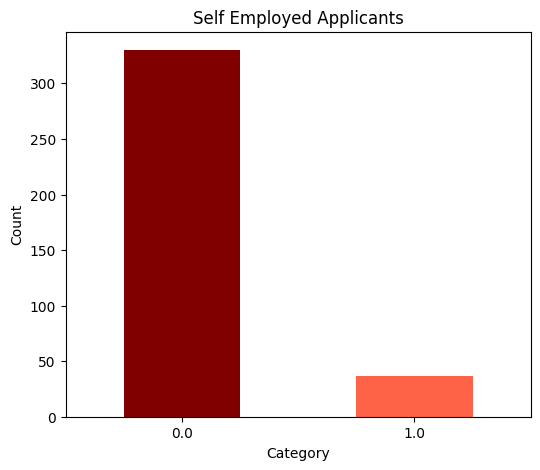

In [179]:
# Chart - 4 visualization code
plt.figure(figsize=(6,5))

df['Self_Employed'].fillna("Unknown").value_counts().plot(
    kind='bar',
    color=['maroon','tomato']
)

plt.title("Self Employed Applicants")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : To identify employment categories.

##### 2. What is/are the insight(s) found from the chart?

Answer : Most applicants are not self-employed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Employment type may influence income stability and loan decisions.

#### Chart - 5

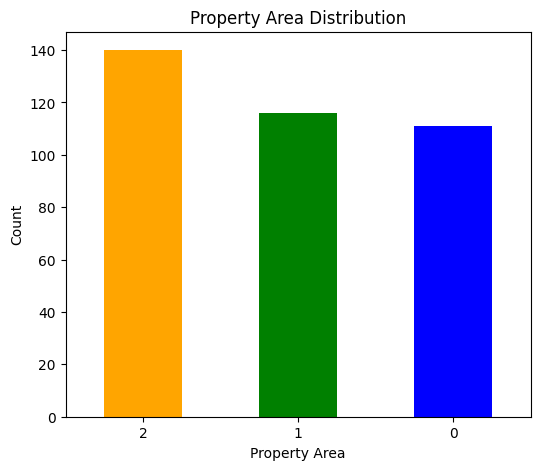

In [180]:
# Chart - 5 visualization code
plt.figure(figsize=(6,5))

df['Property_Area'].value_counts().plot(
    kind='bar',
    color=['orange','green','blue']
)

plt.title("Property Area Distribution")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :To analyze geographical distribution.

##### 2. What is/are the insight(s) found from the chart?

Answer: Applicants belong to Urban, Semiurban and Rural areas, with one category usually dominating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Banks can understand regional demand for loans.

#### Chart - 6

In [110]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [111]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [112]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [113]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [114]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [115]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [116]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [117]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [118]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [119]:
# Pair Plot visualization code


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [120]:
# Handling Missing Values & Missing Value Imputation
categorical_cols = ['Gender', 'Dependents', 'Self_Employed', 'Credit_History']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             367 non-null    float64
 1   Married            367 non-null    int64  
 2   Dependents         367 non-null    object 
 3   Education          367 non-null    int64  
 4   Self_Employed      367 non-null    float64
 5   ApplicantIncome    367 non-null    int64  
 6   CoapplicantIncome  367 non-null    int64  
 7   LoanAmount         367 non-null    float64
 8   Loan_Amount_Term   367 non-null    float64
 9   Credit_History     367 non-null    float64
 10  Property_Area      367 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 31.7+ KB


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [122]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [123]:
# Encode your categorical columns


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [124]:
# Expand Contraction

#### 2. Lower Casing

In [125]:
# Lower Casing

#### 3. Removing Punctuations

In [126]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [127]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [128]:
# Remove Stopwords

In [129]:
# Remove White spaces

#### 6. Rephrase Text

In [130]:
# Rephrase Text

#### 7. Tokenization

In [131]:
# Tokenization

#### 8. Text Normalization

In [132]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [133]:
# POS Taging

#### 10. Text Vectorization

In [134]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [135]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [136]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [137]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [138]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [139]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
inp=df.drop('LoanAmount',axis=1)
out=df['LoanAmount']

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [140]:
# Visualizing evaluation Metric Score chart
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(inp,out,test_size=0.2,random_state=40)
x_train.shape

(293, 10)

In [141]:
x_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
144,1.0,1,2,1,1.0,10890,0,12.0,1.0,0
161,1.0,0,0,1,0.0,2964,0,360.0,0.0,1
359,1.0,0,0,1,0.0,4000,2667,360.0,1.0,1
118,0.0,0,0,1,0.0,1762,2666,360.0,0.0,2
291,1.0,1,2,1,0.0,3166,2833,360.0,1.0,2


In [142]:
from sklearn.linear_model import LinearRegression
m=LinearRegression()
m.fit(x_train,y_train)

LinearRegression()

In [143]:
t=m.predict(x_test)[:5]
t

array([153.53021188, 109.21913057, 177.72054341, 196.65501979,
       140.52433528])

In [144]:
y_test.head().values

array([105., 100., 336., 300., 151.])

In [145]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Lasso,Ridge
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.model_selection import GridSearchCV

#### 2. Cross- Validation & Hyperparameter Tuning

In [146]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
train_pred = m.predict(x_train)
test_pred = m.predict(x_test)
# Fit the Algorithm

# Predict on the model
print(mean_absolute_error(y_train,train_pred))
print(mean_squared_error(y_train,train_pred))

print('*'*30)

print(mean_absolute_error(y_test,test_pred))
print(mean_squared_error(y_test,test_pred))

35.66438905367135
2582.5914637064366
******************************
35.44224468372517
2290.768129044435


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [147]:
# Visualizing evaluation Metric Score chart
from sklearn.linear_model import Lasso
m=Lasso(alpha=0.1)
m.fit(x_train,y_train)

Lasso(alpha=0.1)

#### 2. Cross- Validation & Hyperparameter Tuning

In [148]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
print(mean_absolute_error(y_train,train_pred))
print(mean_squared_error(y_train,train_pred))

print('*'*30)

print(mean_absolute_error(y_test,test_pred))
print(mean_squared_error(y_test,test_pred))

35.66438905367135
2582.5914637064366
******************************
35.44224468372517
2290.768129044435


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [149]:
# Visualizing evaluation Metric Score chart
from sklearn.linear_model import Ridge

#### 2. Cross- Validation & Hyperparameter Tuning

In [150]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
m = Ridge(alpha=0.1)
m.fit(x_train,y_train)
# Fit the Algorithm

# Predict on the model

Ridge(alpha=0.1)

In [151]:
print(mean_absolute_error(y_train,train_pred))
print(mean_squared_error(y_train,train_pred))

print('*'*30)

print(mean_absolute_error(y_test,test_pred))
print(mean_squared_error(y_test,test_pred))

35.66438905367135
2582.5914637064366
******************************
35.44224468372517
2290.768129044435


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***